# Exercise 3

In this exercise, you will analyse a dataset obtained from the London transport system (TfL). The data is in a filled called `tfl_readership.csv` (comma-separated-values format).  As in Exercise 2, we will load and view the data using  `pandas`. 

In [1]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Load data
df_tfl = pd.read_csv('tfl_ridership.csv')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/tfl_ridership.csv'

df_tfl.head(13)

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
0,2000/01,P 01,01 Apr '00,29 Apr '00,29d,884,0,0,210,231,...,0,655,1066,200,2509,0,0,96,45.8,0.0
1,2000/01,P 02,30 Apr '00,27 May '00,28d,949,0,0,214,205,...,0,605,1168,217,2598,0,0,93,46.5,0.0
2,2000/01,P 03,28 May '00,24 Jun '00,28d,945,0,0,209,221,...,0,650,1154,212,2623,0,0,98,47.1,0.0
3,2000/01,P 04,25 Jun '00,22 Jul '00,28d,981,0,0,216,241,...,0,708,1196,214,2761,0,0,105,50.8,0.0
4,2000/01,P 05,23 Jul '00,19 Aug '00,28d,958,0,0,225,248,...,0,730,1165,165,2643,0,0,103,50.3,0.0
5,2000/01,P 06,20 Aug '00,16 Sep '00,28d,984,0,0,243,236,...,0,702,1164,151,2608,0,0,100,49.2,0.0
6,2000/01,P 07,17 Sep '00,14 Oct '00,28d,1001,0,0,205,216,...,0,639,1286,196,2763,0,0,107,48.8,0.0
7,2000/01,P 08,15 Oct '00,11 Nov '00,28d,979,0,0,199,221,...,0,668,1298,220,2819,0,0,113,51.5,0.0
8,2000/01,P 09,12 Nov '00,09 Dec '00,28d,971,0,0,184,212,...,0,640,1302,242,2839,0,0,114,54.0,0.0
9,2000/01,P 10,10 Dec '00,06 Jan '01,28d,912,0,0,192,211,...,0,631,993,195,2359,0,0,90,55.3,0.0


Each row of our data frame represents the average daily ridership over a 28/29 day period for various types of transport and tickets (bus, tube etc.).  We have used the `.head()` command to display the top 13 rows of the data frame (corresponding to one year).  Focusing on the "Tube Total" column, notice the dip in ridership in row 9 (presumably due to Christmas/New Year's), and also the slight dip during the summer (rows 4,5).

In [4]:
#df_tfl.sample(3)  #random sample of 3 rows
df_tfl.tail(3)  #last 3 rows

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
242,2018/19,P 09,11 Nov '18,08 Dec '18,28d,0,1110,1089,0,41,...,1399,249,1017,334,4221,996,557,355,84.1,2.6
243,2018/19,P 10,09 Dec '18,05 Jan '19,28d,0,1001,949,0,38,...,1110,242,632,259,3279,750,414,270,66.3,3.2
244,2018/19,P 11,06 Jan '19,02 Feb '19,28d,0,1036,1075,0,30,...,1310,204,924,305,3809,929,517,333,79.3,2.3


The dataframe contains $N=245$ counting periods (of 28/29 days each) from 1 April 2000 to  2 Feb 2019. We now define a numpy array consisting of the values in the ' Tube Total (000s)' column:

In [5]:
yvals = np.array(df_tfl['Tube Total (000s)'])
N = np.size(yvals)
xvals = np.linspace(1,N,N) #an array containing the values 1,2....,N

We now have a time series consisting of points $(x_i,y_i)$, for $i = 1, \ldots, N$, where $y_i$ is the average daily tube rideship in counting period $x_i = i$.

## 3a) Plot the data in a scatterplot

Text(0, 0.5, 'tfl ridership')

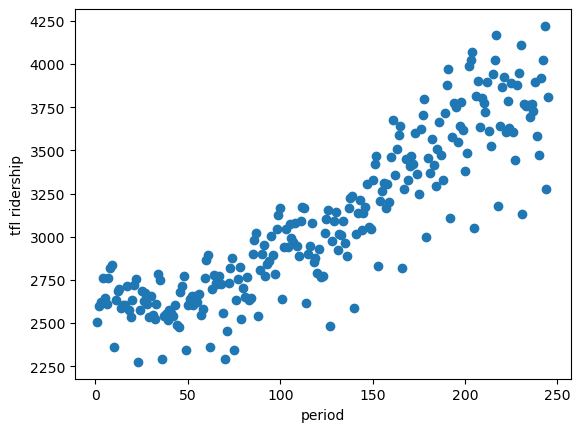

In [8]:
#Your code for scatterplot here
plt.plot(xvals, yvals, 'o')
plt.xlabel('period')
plt.ylabel('tfl ridership')

## 3b) Fit a linear model $f(x) = \beta_0 + \beta_1 x$ to the data

- Print the values of the regression coefficients $\beta_0, \beta_1$ determined using least-squares. 
- Plot the fitted model and the scatterplot on the same plot.
- Compute and print the **MSE** and the $R^2$ coefficient for the fitted model.

All numerical outputs should be displayed to three decimal places.

b1 =  2367.381766477083
b2 =  5.93899011823841
MSE =  45323.63592122834
R-squared =  0.7956113333574004


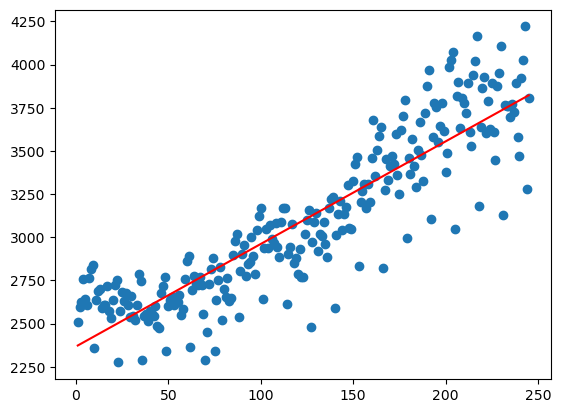

In [13]:
#Your code here
coeffs = np.polyfit(xvals, yvals, 1)
print("b1 = ", coeffs[1])
print("b2 = ", coeffs[0])
plt.scatter(xvals, yvals)
plt.plot(xvals, coeffs[0] * xvals + coeffs[1], color='red')

MSE = np.mean( (yvals - (coeffs[0] * xvals + coeffs[1])) ** 2 )
print("MSE = ", MSE)
R_squared = 1 - (MSE / np.var(yvals))
print("R-squared = ", R_squared)

## 3c)  Plotting the residuals

- Plot the residuals on a scatterplot
- Also plot the residuals over a short duration and comment on whether you can discern any periodic components.

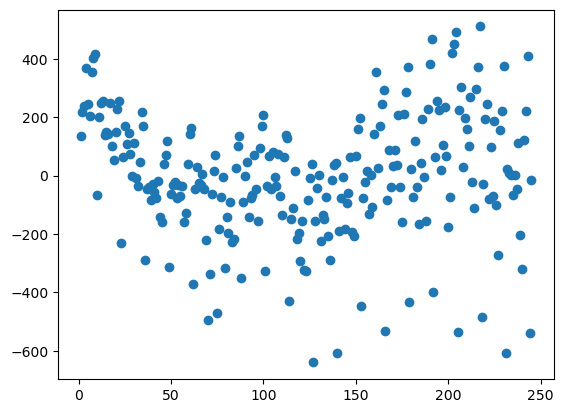

In [14]:
# Your code here
residules = yvals - (coeffs[0] * xvals + coeffs[1])
plt.scatter(xvals, residules)

Text(0.5, 1.0, 'Residuals of the first 50 data points')

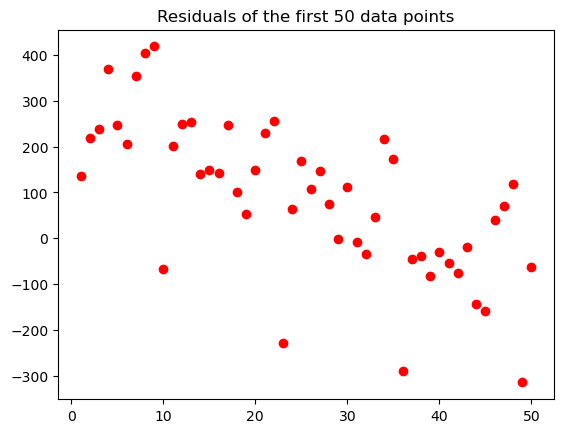

In [19]:
n = 50
plt.scatter(xvals[:n], residules[:n], color='red', label=f'first {n} points')
plt.title(f'Residuals of the first {n} data points')

From visual inspection, there doesn't seem to be a very clear periodic component, but it is possible that there's a sine wave riding on the linear curve

### 3d) Periodogram

- Compute and plot the peridogram of the residuals. (Recall that the periodogram is the squared-magnitude of the DFT coefficients.)
- Identify the indices/frequencies for which the periogram value exceeds **50%** of the maximum. 


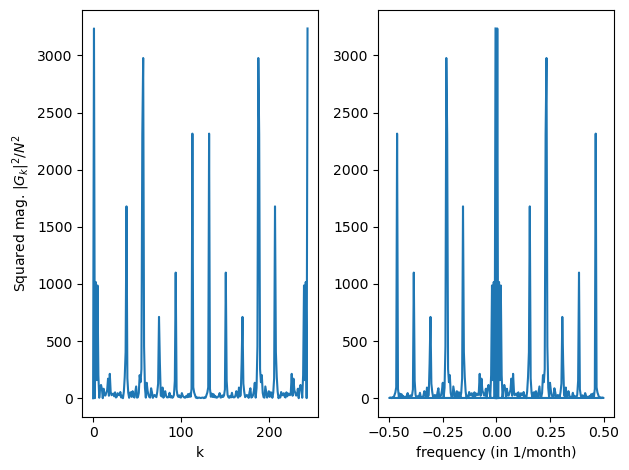

In [21]:
# Your code to compute and plot the periodogram

N = np.size(xvals)
# here T is 1, since data is once every month

# Compute the squared magnitudes of the DFT coefficients -- this is known as the "periodogram"
# Squaring the absolute value gives the periodogram: energy at each frequency.
pgram = np.abs(np.fft.fft(residules, N)/N)**2
indices = np.linspace(0, (N-1), num = N)
freqs_in_hz = np.fft.fftfreq(N)
freqs_in_rads = freqs_in_hz*2*math.pi

plt.subplot(121)
plt.plot(indices, pgram)
plt.xlabel('k')
plt.ylabel('Squared mag. $|G_k|^2/N^2$')
plt.subplot(122)
plt.plot(freqs_in_hz, pgram)
plt.xlabel('frequency (in 1/month)')  # Since units of T is months
plt.savefig('DFT_CO2.pdf', bbox_inches = 'tight')
plt.tight_layout()



In [30]:
pgram[int(indices[0])]

np.float64(3.820292834043844e-25)

In [35]:
periodicity = []
# Your code to identify the indices for which the periodogram value exceeds 50% of the maximum
for i in indices:
    if pgram[int(i)] > 0.5 * np.max(pgram):
        periodicity.append(int(i))
        print(f"Index {i} has periodogram value {pgram[int(i)]}. exceeds 50% of the maximum {np.max(pgram)}")


Index 1.0 has periodogram value 3235.110063584477. exceeds 50% of the maximum 3235.110063584477
Index 38.0 has periodogram value 1678.6437822003115. exceeds 50% of the maximum 3235.110063584477
Index 56.0 has periodogram value 2307.3226191804374. exceeds 50% of the maximum 3235.110063584477
Index 57.0 has periodogram value 2976.790189156972. exceeds 50% of the maximum 3235.110063584477
Index 113.0 has periodogram value 2315.200712605726. exceeds 50% of the maximum 3235.110063584477
Index 132.0 has periodogram value 2315.200712605726. exceeds 50% of the maximum 3235.110063584477
Index 188.0 has periodogram value 2976.790189156972. exceeds 50% of the maximum 3235.110063584477
Index 189.0 has periodogram value 2307.3226191804374. exceeds 50% of the maximum 3235.110063584477
Index 207.0 has periodogram value 1678.6437822003115. exceeds 50% of the maximum 3235.110063584477
Index 244.0 has periodogram value 3235.1100635844755. exceeds 50% of the maximum 3235.110063584477


## 3e) To the residuals,  fit a model of the form  

$$ \beta_{1s} \sin(\omega_1 x) + \beta_{1c} \cos(\omega_1 x) + \beta_{2s} \sin(\omega_2 x) + \beta_{2c} \cos(\omega_2 x) + \ldots + \beta_{Ks} \sin(\omega_K x) + \beta_{Kc} \cos(\omega_K x).$$

The frequencies $\omega_1, \ldots, \omega_K$ in the model are those corresponding to the indices identified in Part 2c. (Hint: Each of the sines and cosines will correspond to one column in your X-matrix.)

- Print the values of the regression coefficients obtained using least-squares. 

All numerical outputs should be displayed to three decimal places.

In [44]:
# Identify dominant frequencies (where periodogram > 50% of max)
dominant_freqs = freqs_in_hz[periodicity]

# Build design matrix with sin and cos columns for each dominant frequency
X_cols = []
for freq in dominant_freqs:
    omega = 2 * np.pi * freq
    X_cols.append(np.sin(omega * xvals))
    X_cols.append(np.cos(omega * xvals))
X = np.column_stack(X_cols)

# Least squares fit to residuals
betas, *_ = np.linalg.lstsq(X, residules, rcond=None)

# Print coefficients to three decimal places
for i, freq in enumerate(dominant_freqs):
    if freq > 0:
        print(f"Frequency {freq:.4f} (cycles/unit): beta_s = {betas[2*i]:.3f}, beta_c = {betas[2*i+1]:.3f}")

Frequency 0.0041 (cycles/unit): beta_s = -25.626, beta_c = 50.778
Frequency 0.1551 (cycles/unit): beta_s = 30.814, beta_c = -27.003
Frequency 0.2286 (cycles/unit): beta_s = -7.790, beta_c = -47.399
Frequency 0.2327 (cycles/unit): beta_s = 40.829, beta_c = 36.191
Frequency 0.4612 (cycles/unit): beta_s = 16.236, beta_c = 45.294


### 3f) The combined fit
- Plot the combined fit together with a scatterplot of the data
- Compute and print the final **MSE** and $R^2$ coefficient. Comment on the improvement over the linear fit.

The combined fit, which corresponds to the full model

$$
f(x) = \beta_0 + \beta_1 x + \beta_{s1} \sin(\omega_1 x) + \beta_{c1} \cos(\omega_1 x) + \ldots + \beta_{sk} \sin(\omega_k x) + \beta_{ck} \cos(\omega_k x),
$$

can be obtained by adding the fits in parts 2b) and 2e).

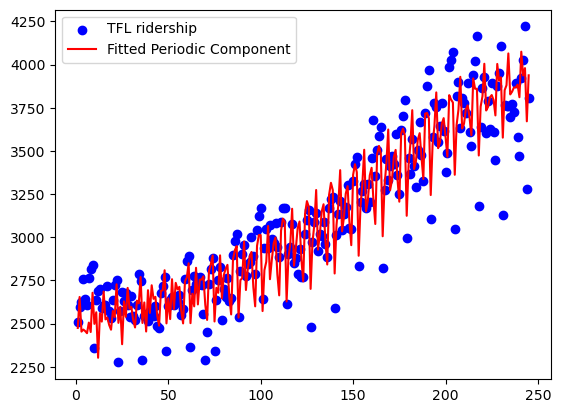

In [48]:
# Your code here
plt.scatter(xvals, yvals, label='TFL ridership', color='blue')
plt.plot(xvals, X @ betas + coeffs[0] * xvals + coeffs[1], label='Fitted Periodic Component', color='red')
plt.legend()

In [49]:
MSE = np.mean( (yvals - (X @ betas + coeffs[0] * xvals + coeffs[1])) ** 2 )
print("MSE = ", MSE)
R_squared = 1 - (MSE / np.var(yvals))
print("R-squared = ", R_squared)

MSE =  20297.5011877725
R-squared =  0.9084676434354129


MSE has improved by about 50%, showing that the combined fit has smaller error. R-squared value also improves noticably, indicating that the new fit better predidcts the data variants. 